## LGBM vs XGBoos

#### 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\Assignments question\XGBM & LGBM (1)\XGBM & LGBM\Titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### 3. EDA (Exploratory Data Analysis)

Check Info & Missing Values

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

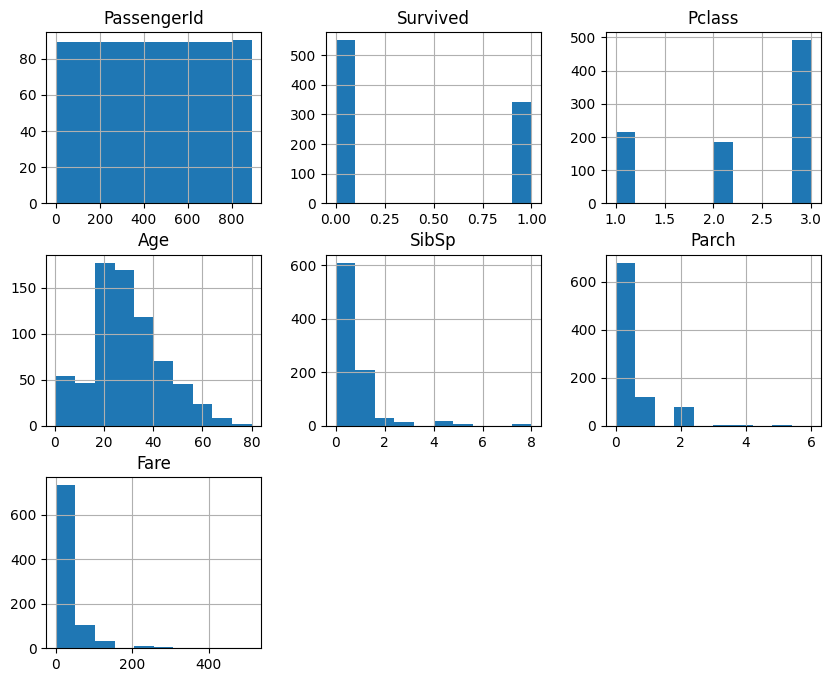

In [5]:
#Histogram
df.hist(figsize=(10,8))
plt.show()

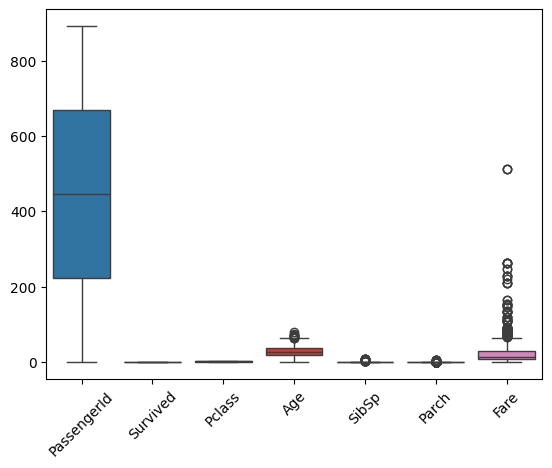

In [6]:
#Boxplot
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=45)
plt.show()

Survival Count

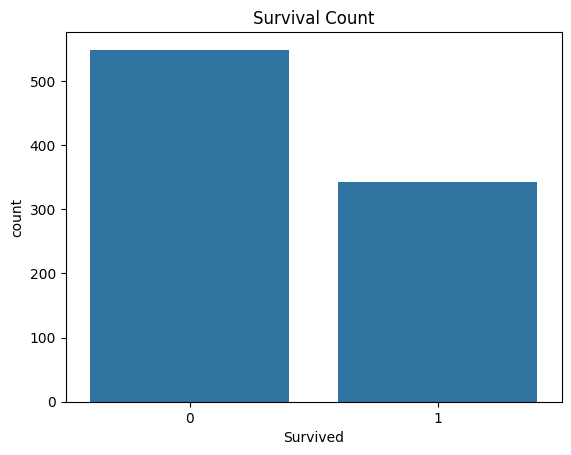

In [7]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

Relationship

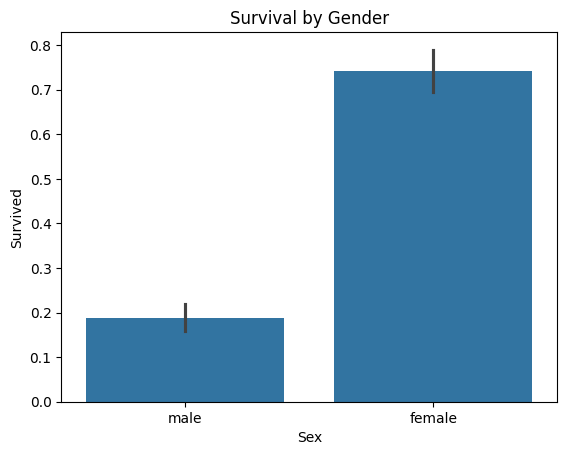

In [8]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

##### 4. Data Preprocessing

Handle Missing Values

In [9]:
#  Print current column names
print(df.columns.tolist())

# Standardize column names (lowercase, no extra spaces)
df.columns = df.columns.str.strip().str.lower()

#  Fill missing 'age' with median
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].median())

#  Fill missing 'embarked' with mode
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop 'cabin' column if it exists
if 'cabin' in df.columns:
    df = df.drop('cabin', axis=1)

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


Encode Categorical Variables

In [10]:
print(df.select_dtypes(include='object').columns)
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

Index(['name', 'sex', 'ticket', 'embarked'], dtype='object')


Drop Irrelevant Columns

In [11]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Drop only if columns exist
cols_to_drop = ['name', 'ticket', 'passengerid']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

#### 5. Split Features & Target

In [12]:
X = df.drop('survived', axis=1)
y = df['survived']

#### 6. Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#### 7. LightGBM Model

In [14]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("LGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 195
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


#### 8. XGBoost Model

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       105
           1       0.77      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



C:\Users\suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:51:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### 9. Cross Validation

In [16]:
from sklearn.model_selection import cross_val_score

print("LGBM CV:", cross_val_score(lgbm, X, y, cv=5).mean())
print("XGB CV:", cross_val_score(xgb, X, y, cv=5).mean())

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:51:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:51:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:51:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:51:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

XGB CV: 0.8148389931579938


C:\Users\suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:51:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### 10. Comparison Visualization

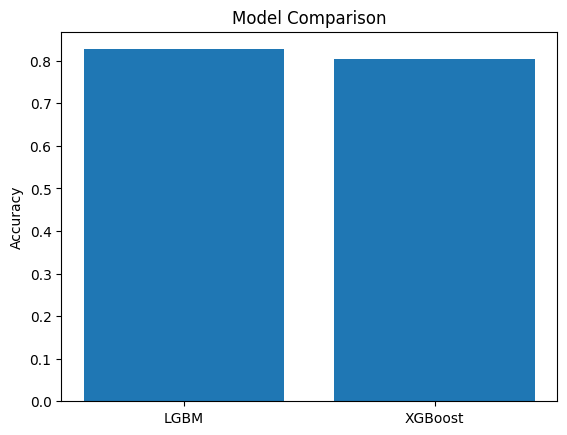

In [17]:
models = ['LGBM', 'XGBoost']
accuracy = [
    accuracy_score(y_test, y_pred_lgbm),
    accuracy_score(y_test, y_pred_xgb)
]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

#### 11. Final Conclusion 
# LightGBM
Faster training
Handles large data efficiently
# XGBoost
Better accuracy (sometimes)
More robust to overfitting
#Comparison
Feature	        LightGBM	           XGBoost
Speed	        Faster	               Slower
Accuracy	    Good                   Slightly better
Memory	        Low	                   Higher